In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

In [17]:
# Context source data
train_business = pd.read_csv("train_business_context_cleaned.csv"
)

test_business = pd.read_csv( "test_business_context_cleaned.csv"
)

# Already-transformed context vectors
train_vectors = pd.read_csv("train_context_vectors.csv"
)

test_vectors = pd.read_csv( "test_context_vectors.csv"
)

# Bandit interactions
train_interactions = pd.read_csv( "prepared_bandit_interactions.csv"
)

test_interactions = pd.read_csv( "test_bandit_interactions.csv"
)

print("Train business:", train_business.shape)
print("Test business:", test_business.shape)
print("Train vectors:", train_vectors.shape)
print("Test vectors:", test_vectors.shape)
print("Train interactions:", train_interactions.shape)
print("Test interactions:", test_interactions.shape)

Train business: (798, 31)
Test business: (200, 31)
Train vectors: (798, 38)
Test vectors: (200, 38)
Train interactions: (63840, 9)
Test interactions: (16000, 17)


In [18]:
assert len(train_business) == len(train_vectors)
assert len(test_business) == len(test_vectors)

print("PASS: Number of business rows matches number of context vectors.")

PASS: Number of business rows matches number of context vectors.


In [19]:
train_context = pd.concat(
    [
        train_business[["business_id"]].reset_index(drop=True),
        train_vectors.reset_index(drop=True)
    ],
    axis=1
)

test_context = pd.concat(
    [
        test_business[["business_id"]].reset_index(drop=True),
        test_vectors.reset_index(drop=True)
    ],
    axis=1
)

print("Train context:", train_context.shape)
print("Test context:", test_context.shape)

display(train_context.head())

Train context: (798, 39)
Test context: (200, 39)


,business_id,log_numeric__monthly_revenue_proxy_inr,log_numeric__monthly_profit_proxy_inr,log_numeric__revenue_per_employee,numeric__female_majority_owned,numeric__migrant_owner,numeric__previously_unemployed_owner,numeric__primary_income_earner,numeric__owner_has_contract_job,numeric__household_size_proxy,...,categorical__city_Jaipur,categorical__city_Kochi,categorical__city_Ludhiana,categorical__city_Mumbai,categorical__city_Sehore,categorical__city_Surat,categorical__city_Varanasi,categorical__sector_Manufacturing,categorical__sector_Other Services,categorical__sector_Retail
0,V2V0001,-0.184221,0.436989,-0.578424,-0.391381,2.672612,-0.531938,0.630514,-0.349804,-0.298912,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,V2V0003,0.310927,1.386138,0.962899,-0.391381,-0.374166,-0.531938,0.630514,-0.349804,-1.374699,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,V2V0004,-0.634729,0.748170,-1.010052,-0.391381,-0.374166,-0.531938,0.630514,-0.349804,-1.276901,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,V2V0005,0.103711,-0.736967,-0.302559,-0.391381,-0.374166,-0.531938,0.630514,-0.349804,-1.570297,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,V2V0006,0.602974,0.349274,1.242712,-0.391381,2.672612,-0.531938,-1.586007,-0.349804,-0.298912,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
print(
    "Duplicate train business IDs:",
    train_context["business_id"].duplicated().sum()
)

print(
    "Duplicate test business IDs:",
    test_context["business_id"].duplicated().sum()
)

Duplicate train business IDs: 0
Duplicate test business IDs: 0


In [21]:
CONTEXT_FEATURES = [
    col for col in train_context.columns
    if col != "business_id"
]

print("Number of context features:", len(CONTEXT_FEATURES))

for i, feature in enumerate(CONTEXT_FEATURES, start=1):
    print(i, feature)

Number of context features: 38
1 log_numeric__monthly_revenue_proxy_inr
2 log_numeric__monthly_profit_proxy_inr
3 log_numeric__revenue_per_employee
4 numeric__female_majority_owned
5 numeric__migrant_owner
6 numeric__previously_unemployed_owner
7 numeric__primary_income_earner
8 numeric__owner_has_contract_job
9 numeric__household_size_proxy
10 numeric__employee_count
11 numeric__bank_account
12 numeric__has_loan
13 numeric__friends_family_finance
14 numeric__sells_on_credit
15 numeric__buys_on_credit
16 numeric__mobile_money
17 numeric__computer_or_tablet
18 numeric__electricity
19 numeric__digital_adoption_score
20 numeric__household_based_business
21 numeric__non_fixed_premises
22 numeric__pl_statement
23 numeric__management_score_proxy
24 numeric__profit_margin
25 numeric__finance_constraint
26 numeric__customer_reach_constraint
27 numeric__management_constraint
28 categorical__city_Hyderabad
29 categorical__city_Jaipur
30 categorical__city_Kochi
31 categorical__city_Ludhiana
32 ca

In [22]:
assert (
    train_context[CONTEXT_FEATURES].columns.tolist()
    ==
    test_context[CONTEXT_FEATURES].columns.tolist()
)

print("PASS: Train and test context features match.")

PASS: Train and test context features match.


In [23]:
train_merged = train_interactions.merge(
    train_context,
    on="business_id",
    how="left",
    validate="many_to_one"
)

print("Original train interactions:", len(train_interactions))
print("Merged train interactions:", len(train_merged))

assert len(train_merged) == len(train_interactions)

print("PASS: No training interactions were lost.")

Original train interactions: 63840
Merged train interactions: 63840
PASS: No training interactions were lost.


In [24]:
test_merged = test_interactions.merge(
    test_context,
    on="business_id",
    how="left",
    validate="many_to_one"
)

print("Original test interactions:", len(test_interactions))
print("Merged test interactions:", len(test_merged))

assert len(test_merged) == len(test_interactions)

print("PASS: No test interactions were lost.")

Original test interactions: 16000
Merged test interactions: 16000
PASS: No test interactions were lost.


In [25]:
print(
    "Missing train context values:",
    train_merged[CONTEXT_FEATURES].isna().sum().sum()
)

print(
    "Missing test context values:",
    test_merged[CONTEXT_FEATURES].isna().sum().sum()
)

Missing train context values: 0
Missing test context values: 0


In [26]:
ACTION_IDS = sorted(
    train_merged["action_id"].unique()
)

print("Number of actions:", len(ACTION_IDS))
print("Actions:", ACTION_IDS)

Number of actions: 10
Actions: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10']


In [27]:
invalid_test_actions = (
    set(test_merged["action_id"])
    -
    set(ACTION_IDS)
)

print("Invalid test actions:", invalid_test_actions)

assert len(invalid_test_actions) == 0

Invalid test actions: set()


In [28]:
print("Train reward range:")
print(
    train_merged["reward"].min(),
    "to",
    train_merged["reward"].max()
)

print("\nTest reward range:")
print(
    test_merged["reward"].min(),
    "to",
    test_merged["reward"].max()
)

assert train_merged["reward"].between(0, 1).all()
assert test_merged["reward"].between(0, 1).all()

print("\nPASS: Rewards are within [0,1].")

Train reward range:
0.09 to 1.0

Test reward range:
0.09 to 1.0

PASS: Rewards are within [0,1].


In [29]:
X_train = train_context[
    CONTEXT_FEATURES
].to_numpy(dtype=float)

X_test = test_context[
    CONTEXT_FEATURES
].to_numpy(dtype=float)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (798, 38)
X_test shape: (200, 38)


In [30]:
train_reward_lookup = {
    (
        row["business_id"],
        row["round"],
        row["action_id"]
    ): row["reward"]
    for _, row in train_merged.iterrows()
}

test_reward_lookup = {
    (
        row["business_id"],
        row["round"],
        row["action_id"]
    ): row["reward"]
    for _, row in test_merged.iterrows()
}

print("Train reward entries:", len(train_reward_lookup))
print("Test reward entries:", len(test_reward_lookup))

Train reward entries: 63840
Test reward entries: 16000


In [31]:
train_context_lookup = (
    train_context
    .set_index("business_id")[CONTEXT_FEATURES]
)

test_context_lookup = (
    test_context
    .set_index("business_id")[CONTEXT_FEATURES]
)

In [32]:
X_train_model = np.column_stack(
    [
        np.ones(len(X_train)),
        X_train
    ]
)

X_test_model = np.column_stack(
    [
        np.ones(len(X_test)),
        X_test
    ]
)

N_FEATURES = X_train_model.shape[1]

print("LinUCB feature dimension:", N_FEATURES)

LinUCB feature dimension: 39


In [33]:
class DisjointLinUCB:

    def __init__(
        self,
        n_actions,
        n_features,
        alpha=1.0
    ):
        self.n_actions = n_actions
        self.n_features = n_features
        self.alpha = alpha

        self.A = [
            np.eye(n_features)
            for _ in range(n_actions)
        ]

        self.b = [
            np.zeros(n_features)
            for _ in range(n_actions)
        ]

    def score(self, x, action_index):

        A = self.A[action_index]
        b = self.b[action_index]

        theta = np.linalg.solve(A, b)

        estimated_reward = theta @ x

        A_inv_x = np.linalg.solve(A, x)

        uncertainty = np.sqrt(
            x @ A_inv_x
        )

        return (
            estimated_reward
            +
            self.alpha * uncertainty
        )

    def select_action(self, x):

        scores = np.array([
            self.score(x, i)
            for i in range(self.n_actions)
        ])

        selected = int(
            np.argmax(scores)
        )

        return selected, scores

    def update(
        self,
        x,
        action_index,
        reward
    ):

        self.A[action_index] += np.outer(
            x,
            x
        )

        self.b[action_index] += (
            reward * x
        )

In [34]:
ALPHA = 1.0

ACTION_TO_INDEX = {
    action: i
    for i, action in enumerate(ACTION_IDS)
}

INDEX_TO_ACTION = {
    i: action
    for action, i in ACTION_TO_INDEX.items()
}

linucb = DisjointLinUCB(
    n_actions=len(ACTION_IDS),
    n_features=N_FEATURES,
    alpha=ALPHA
)

print("LinUCB ready.")

LinUCB ready.


In [35]:
train_decisions = (
    train_interactions[
        ["business_id", "round"]
    ]
    .drop_duplicates()
    .sort_values(
        ["round", "business_id"]
    )
    .reset_index(drop=True)
)

print(
    "Training decisions:",
    len(train_decisions)
)

Training decisions: 6384


In [36]:
training_history = []

for _, decision in train_decisions.iterrows():

    business_id = decision["business_id"]
    round_id = decision["round"]

    # Get context
    x = train_context_lookup.loc[
        business_id
    ].to_numpy(dtype=float)

    # Add intercept
    x = np.concatenate(
        [[1.0], x]
    )

    # LinUCB selects one action
    selected_index, scores = (
        linucb.select_action(x)
    )

    selected_action = INDEX_TO_ACTION[
        selected_index
    ]

    # Get reward for selected action
    reward = train_reward_lookup[
        (
            business_id,
            round_id,
            selected_action
        )
    ]

    # Update LinUCB
    linucb.update(
        x,
        selected_index,
        reward
    )

    training_history.append({
        "business_id": business_id,
        "round": round_id,
        "chosen_action": selected_action,
        "reward": reward
    })

training_history = pd.DataFrame(
    training_history
)

print("Training complete!")
print(
    "Training decisions:",
    len(training_history)
)

Training complete!
Training decisions: 6384


In [37]:
print(
    "Training average reward:",
    training_history["reward"].mean()
)

print(
    "Training cumulative reward:",
    training_history["reward"].sum()
)

print("\nActions selected during training:")
print(
    training_history[
        "chosen_action"
    ].value_counts().sort_index()
)


Training average reward: 0.8624791666666667
Training cumulative reward: 5506.067

Actions selected during training:
chosen_action
A01     902
A02     972
A03    1029
A04     343
A05     753
A06     861
A07     333
A08     305
A09     618
A10     268
Name: count, dtype: int64


In [38]:
test_decisions = (
    test_interactions[
        ["business_id", "round"]
    ]
    .drop_duplicates()
    .sort_values(
        ["round", "business_id"]
    )
    .reset_index(drop=True)
)

print(
    "Test decisions:",
    len(test_decisions)
)

Test decisions: 1600


In [39]:
evaluation_history = []

for _, decision in test_decisions.iterrows():

    business_id = decision["business_id"]
    round_id = decision["round"]

    # Context
    x = test_context_lookup.loc[
        business_id
    ].to_numpy(dtype=float)

    x = np.concatenate(
        [[1.0], x]
    )

    # Select action
    selected_index, scores = (
        linucb.select_action(x)
    )

    selected_action = INDEX_TO_ACTION[
        selected_index
    ]

    # Reward received by selected action
    selected_reward = test_reward_lookup[
        (
            business_id,
            round_id,
            selected_action
        )
    ]

    # Best available reward
    available_rewards = [
        test_reward_lookup[
            (
                business_id,
                round_id,
                action
            )
        ]
        for action in ACTION_IDS
    ]

    best_reward = max(
        available_rewards
    )

    regret = (
        best_reward
        -
        selected_reward
    )

    evaluation_history.append({
        "business_id": business_id,
        "round": round_id,
        "chosen_action": selected_action,
        "reward": selected_reward,
        "best_reward": best_reward,
        "regret": regret
    })

evaluation_history = pd.DataFrame(
    evaluation_history
)

print("Evaluation complete!")
print(
    "Test decisions:",
    len(evaluation_history)
)

Evaluation complete!
Test decisions: 1600


In [40]:
average_reward = (
    evaluation_history["reward"].mean()
)

cumulative_reward = (
    evaluation_history["reward"].sum()
)

average_regret = (
    evaluation_history["regret"].mean()
)

cumulative_regret = (
    evaluation_history["regret"].sum()
)

print("====================================")
print("LINUCB TEST EVALUATION")
print("====================================")

print(
    "Average reward:",
    round(average_reward, 4)
)

print(
    "Cumulative reward:",
    round(cumulative_reward, 4)
)

print(
    "Average regret:",
    round(average_regret, 4)
)

print(
    "Cumulative regret:",
    round(cumulative_regret, 4)
)

LINUCB TEST EVALUATION
Average reward: 0.8595
Cumulative reward: 1375.259
Average regret: 0.1138
Cumulative regret: 182.106


In [41]:
action_counts = (
    evaluation_history[
        "chosen_action"
    ]
    .value_counts()
    .sort_index()
)

print(action_counts)

chosen_action
A01    240
A02    192
A03    120
A04    152
A05    168
A06    216
A07    128
A08    120
A09    176
A10     88
Name: count, dtype: int64


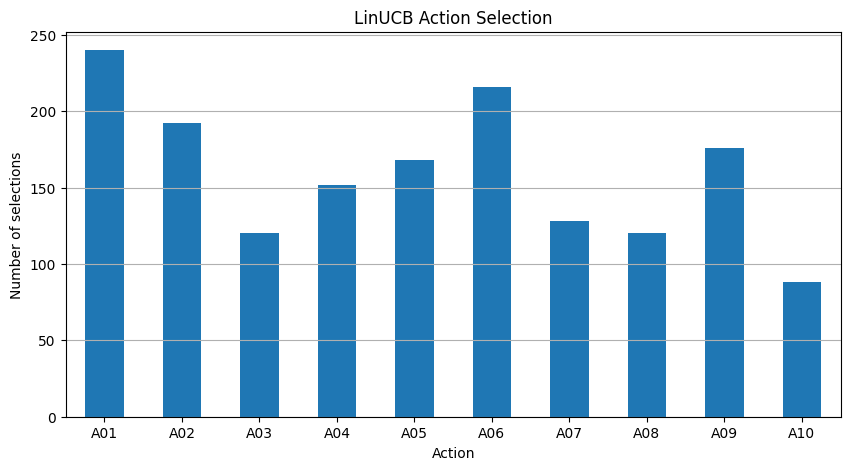

In [42]:
plt.figure(figsize=(10, 5))

action_counts.plot(
    kind="bar"
)

plt.xlabel("Action")
plt.ylabel("Number of selections")
plt.title("LinUCB Action Selection")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

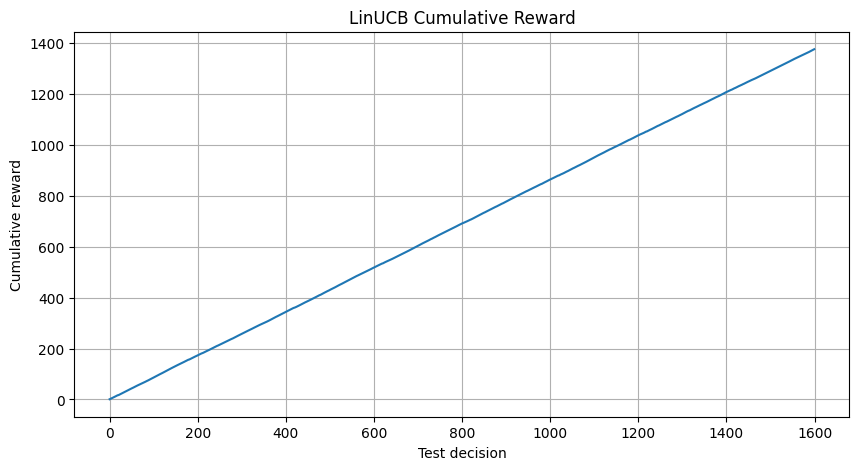

In [43]:
evaluation_history[
    "cumulative_reward"
] = evaluation_history[
    "reward"
].cumsum()

plt.figure(figsize=(10, 5))

plt.plot(
    evaluation_history[
        "cumulative_reward"
    ]
)

plt.xlabel("Test decision")
plt.ylabel("Cumulative reward")
plt.title("LinUCB Cumulative Reward")

plt.grid(True)

plt.show()

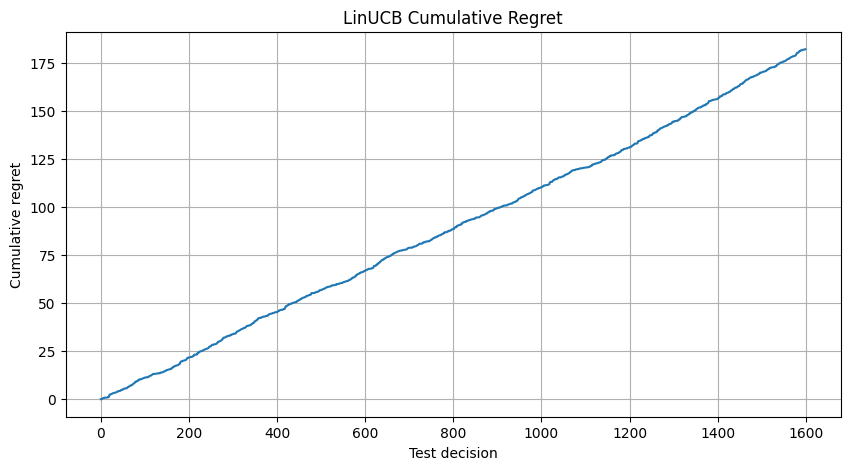

In [44]:
evaluation_history[
    "cumulative_regret"
] = evaluation_history[
    "regret"
].cumsum()

plt.figure(figsize=(10, 5))

plt.plot(
    evaluation_history[
        "cumulative_regret"
    ]
)

plt.xlabel("Test decision")
plt.ylabel("Cumulative regret")
plt.title("LinUCB Cumulative Regret")

plt.grid(True)

plt.show()

In [46]:
RESULTS_DIR = Path("/content/results")
RESULTS_DIR.mkdir(exist_ok=True)

# Integrated datasets
train_merged.to_csv(
    RESULTS_DIR / "integrated_train_bandit.csv",
    index=False
)

test_merged.to_csv(
    RESULTS_DIR / "integrated_test_bandit.csv",
    index=False
)

# Training
training_history.to_csv(
    RESULTS_DIR / "linucb_training_history.csv",
    index=False
)

# Evaluation
evaluation_history.to_csv(
    RESULTS_DIR / "linucb_evaluation.csv",
    index=False
)

# Action selection
action_counts.rename("selection_count").to_csv(
    RESULTS_DIR / "linucb_action_selection.csv"
)

# Summary
summary = pd.DataFrame({
    "metric": [
        "alpha",
        "number_of_actions",
        "number_of_context_features",
        "training_decisions",
        "test_decisions",
        "average_reward",
        "cumulative_reward",
        "average_regret",
        "cumulative_regret"
    ],
    "value": [
        ALPHA,
        len(ACTION_IDS),
        len(CONTEXT_FEATURES),
        len(training_history),
        len(evaluation_history),
        average_reward,
        cumulative_reward,
        average_regret,
        cumulative_regret
    ]
})

summary.to_csv(
    RESULTS_DIR / "linucb_summary.csv",
    index=False
)

display(summary)

,metric,value
0,alpha,1.000000
1,number_of_actions,10.000000
2,number_of_context_features,38.000000
3,training_decisions,6384.000000
4,test_decisions,1600.000000
5,average_reward,0.859537
6,cumulative_reward,1375.259000
7,average_regret,0.113816
8,cumulative_regret,182.106000


In [47]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/linucb_results",
    "zip",
    RESULTS_DIR
)

files.download("/content/linucb_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>